In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
!pip install retinaface
!pip install deepface

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 35.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 64.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 69.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 10.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 69.2 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of retinaface to determine which version is compatible with other requirements. This could take a while.
ERROR: Cannot install retinaface==0.0.1, retinaface==0.0.2, retinaface==0.0.3, retinaface==0.0.4, retinaface==0.0.5, retinaface==0.0.6, retinaface==1.1.0 and retinaface==1.1.1 because these package versions have conflicting dependenc

In [ ]:
directory = "/content/gdrive/My Drive/Colab Notebooks/CS/Dataset/"
dir = "/content/gdrive/My Drive/Colab Notebooks/CS/"

In [ ]:
import os
import cv2
from retinaface import RetinaFace

def classify_and_move_faces(directory, target_size=(1280, 720)):
    categories = {'under4': [], '4': [], 'over4': []}
    # 각 카테고리에 대한 폴더 생성
    for category in categories.keys():
        category_path = os.path.join(directory, category)
        if not os.path.exists(category_path):
            os.makedirs(category_path)

    total_images = 0
    moved_images = 0

    for filename in os.listdir(directory):
        if filename.endswith(".jpg") and filename[0].isdigit():
            total_images += 1
            image_path = os.path.join(directory, filename)
            image = cv2.imread(image_path)
            image = cv2.resize(image, target_size)

            # 파일명에서 첫 번째 숫자 추출
            first_digit = int(filename[0])
            if first_digit < 4:
                category = 'under4'
            elif first_digit == 4:
                category = '4'
            else:
                category = 'over4'

            # 얼굴 검출
            faces = RetinaFace.detect_faces(image_path)
            if faces:
                moved_images += 1
                dest_path = os.path.join(directory, category, filename)
                cv2.imwrite(dest_path, image)  # 이미지 저장
                os.remove(image_path)  # 원본 이미지 삭제
                print(f"Moved {filename} to '{category}'")

    print(f"Total images processed: {total_images}")
    print(f"Images moved: {moved_images}")

# 데이터셋 디렉토리 지정 및 함수 호출
new_directory = "/content/gdrive/My Drive/Colab Notebooks/CS/Dataset/"
classify_and_move_faces(new_directory)


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.optimizers import Nadam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

def evaluate_and_plot(model, history, x_test, y_test):
    scores = model.evaluate(x_test, y_test, verbose=0)
    print("ACC(%):", scores[1] * 100)
    print("LOSS: ", scores[0])

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # 선 스타일 변경
    plt.plot(epochs, acc, 'b-', label='Training accuracy')  # 파란색 선으로 변경
    plt.plot(epochs, val_acc, 'r-', label='Validation accuracy')  # 빨간색 선으로 변경
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'b-', label='Training loss')  # 파란색 선으로 변경
    plt.plot(epochs, val_loss, 'r-', label='Validation loss')  # 빨간색 선으로 변경
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Nadam, Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import Callback

def load_data_and_split_efficientnet(directory, target_size=(224, 224), test_size=0.3, random_state=42):
    images = []
    labels = []
    categories = {'under4': 0, '4': 1, 'over4': 2}

    for category, label in categories.items():
        folder_path = os.path.join(directory, category)
        for filename in os.listdir(folder_path):
            img_path = os.path.join(folder_path, filename)
            image = load_img(img_path, target_size=target_size)
            image = img_to_array(image)
            image = np.expand_dims(image, axis=0)
            images.append(image)
            labels.append(label)

    images = np.vstack(images)
    labels = to_categorical(np.array(labels), num_classes=3)
    x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=test_size, random_state=random_state)
    return x_train, y_train, x_test, y_test

def build_model_efficientnet(num_classes):
    base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
    base_model.trainable = False  # Freeze the convolutional base

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        BatchNormalization(),
        Dropout(0.5),
        Dense(512, activation='elu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(1024, activation='elu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(optimizer=Nadam(lr=0.1),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

class CustomReduceLROnPlateau(Callback):
    def __init__(self, factor=0.7, patience=3, min_lr=1e-7, verbose=0):
        super().__init__()
        self.factor = factor
        self.patience = patience
        self.min_lr = min_lr
        self.verbose = verbose
        self.wait = 0
        self.best = np.Inf

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = np.mean([logs.get('loss'), logs.get('val_loss')])
        if np.less(current, self.best):
            self.best = current
            self.wait = 0
        else:
            self.wait += 1
            if self.wait >= self.patience:
                new_lr = max(self.model.optimizer.lr * self.factor, self.min_lr)
                self.model.optimizer.lr.assign(new_lr)
                if self.verbose > 0:
                    print(f'\nEpoch {epoch+1}: ReduceLROnPlateau reducing learning rate to {new_lr:.2e}.')
                self.wait = 0

class CustomEarlyStopping(Callback):
    def __init__(self, patience=9, verbose=0, restore_best_weights=True):
        super().__init__()
        self.patience = patience
        self.verbose = verbose
        self.wait = 0
        self.best = -np.Inf  # accuracy나 val_accuracy가 더 클수록 좋은 것이므로 -np.Inf로 초기화합니다.
        self.stopped_epoch = 0
        self.restore_best_weights = restore_best_weights
        self.best_weights = None  # best_weights 속성 초기화

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        current = np.mean([logs.get('accuracy'), logs.get('val_accuracy')])
        if np.greater(current, self.best):
            self.best = current
            self.wait = 0
            if self.restore_best_weights:
                self.best_weights = self.model.get_weights()  # 최적의 가중치를 저장
        else:
            self.wait += 1
            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.model.stop_training = True
                if self.verbose > 0:
                    print(f'\nEpoch {epoch+1}: EarlyStopping')
                if self.restore_best_weights:
                    self.model.set_weights(self.best_weights)  # 최적의 가중치로 복원

def compile_and_train_efficientnet(x_train, y_train, x_test, y_test):
    model = build_model_efficientnet(y_train.shape[1])
    reduce_lr = CustomReduceLROnPlateau(verbose=2)
    early_stop = CustomEarlyStopping(verbose=2)
    history = model.fit(x_train, y_train, batch_size=16, epochs=100, validation_split=0.3,
                        callbacks=[reduce_lr, early_stop],
                        shuffle=True, verbose=1)
    return model, history

x_train, y_train, x_test, y_test = load_data_and_split_efficientnet(directory)
model, history = compile_and_train_efficientnet(x_train, y_train, x_test, y_test)

evaluate_and_plot(model, history, x_test, y_test)


In [ ]:
from tensorflow.keras.models import load_model
#모델 저장
model.save(dir + '/EfficientNetB8282.keras')

# 모델 로드
loaded_model = load_model(dir+'/EfficientNetB8282.keras')

# 모델 요약 정보 출력
loaded_model.summary()


In [ ]:

def open_fullscreen_alert(message):
    js_code = f'''
    const newWindow = window.open("", "_blank", "width=800,height=600");
    newWindow.document.write(`
        <html>
        <head>
            <title>Alert</title>
            <style>
                body {{
                    display: flex;
                    justify-content: center;
                    align-items: center;
                    height: 100vh;
                    margin: 0;
                    background-color: black;
                }}
                h1 {{
                    color: red;
                    font-size: 72px;
                    text-align: center;
                }}
            </style>
        </head>
        <body>
            <h1>{message}</h1>
        </body>
        </html>
    `);
    newWindow.document.close();
    '''
    display(Javascript(js_code))

def open_small_alert(message):
    js_code = f'''
    const newWindow = window.open("", "_blank", "width=800,height=200");
    newWindow.document.write(`
        <html>
        <head>
            <title>Alert</title>
            <style>
                body {{
                    display: flex;
                    justify-content: center;
                    align-items: flex-start;
                    height: 100vh;
                    margin: 0;
                    padding-top: 20px;
                    background-color: white;
                }}
                h1 {{
                    color: red;
                    font-size: 36px;
                    text-align: center;
                }}
            </style>
        </head>
        <body>
            <h1>{message}</h1>
        </body>
        </html>
    `);
    newWindow.document.close();
    '''
    display(Javascript(js_code))


<IPython.core.display.Javascript object>

1/1 [==============================] - 12s 12s/step


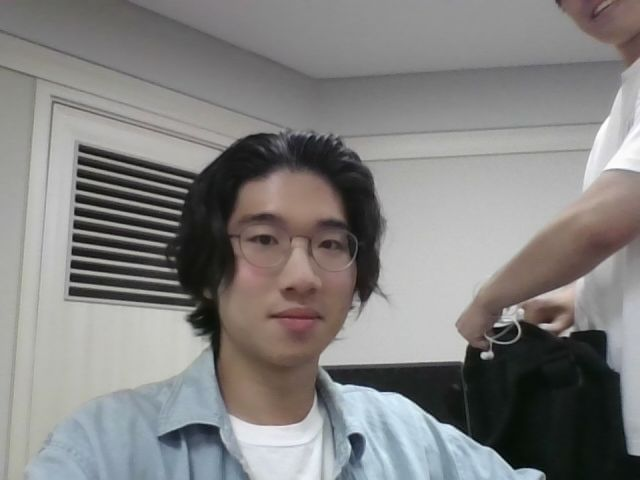

Predicted Class: over4, Probability: 0.97


<IPython.core.display.Javascript object>

1/1 [==============================] - 0s 84ms/step


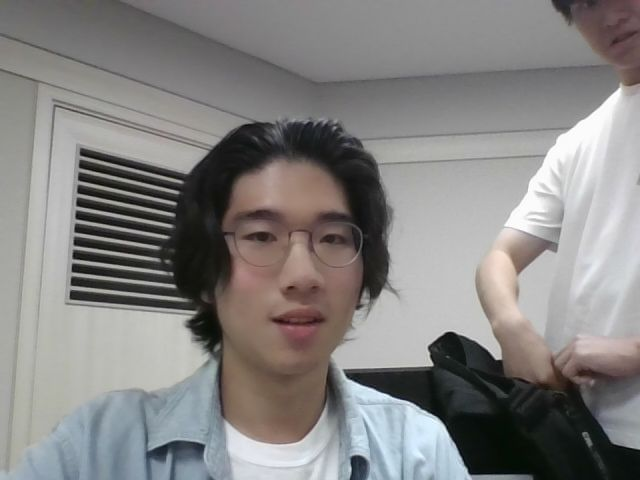

Predicted Class: 4, Probability: 0.62


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

1/1 [==============================] - 0s 77ms/step


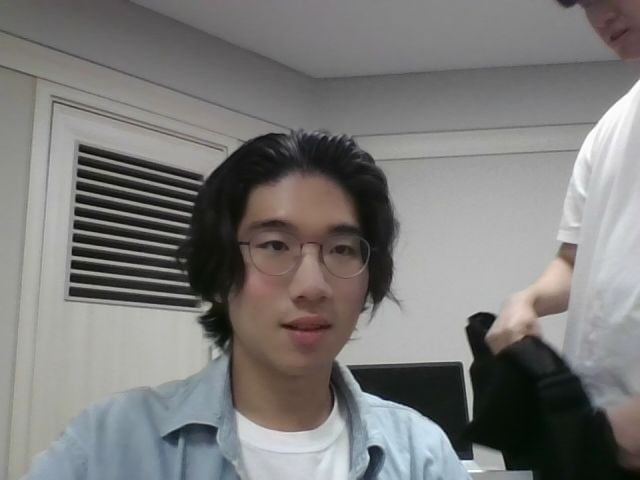

Predicted Class: over4, Probability: 0.56


KeyboardInterrupt: 

In [ ]:
from IPython.display import display, Javascript
from base64 import b64decode
import numpy as np
from PIL import Image
import io
from retinaface import RetinaFace
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import load_model
import time
import cv2

# Load model
model_path = "/content/gdrive/My Drive/Colab Notebooks/CS/EfficientNetB8282.keras"
model = load_model(model_path)

# Class labels
class_labels = ['under4', '4', 'over4']

def take_photo(quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();
      await new Promise((resolve) => setTimeout(resolve, 5000)); // 5 seconds delay for capturing
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getTracks().forEach(track => track.stop());
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    image = Image.open(io.BytesIO(binary))
    return image

def preprocess_image(image, target_size=(224, 224)):
    image = image.resize(target_size, Image.NEAREST)
    image = img_to_array(image)
    image = np.expand_dims(image, axis=0)
    return image

def predict_and_alert(image):
    processed_image = preprocess_image(image)
    predictions = model.predict(processed_image)
    predicted_class = np.argmax(predictions, axis=1)[0]
    probability = np.max(predictions)
    result = class_labels[predicted_class]

    display(image)  # Display the captured image
    print(f"Predicted Class: {result}, Probability: {probability:.2f}")

    if result == 'under4':
        open_fullscreen_alert('화면과 너무 가깝습니다')
    elif result == '4':
        open_small_alert('모니터 주시 거리의 주의가 필요합니다')

# Main loop for real-time processing
while True:
    image = take_photo()
    predict_and_alert(image)
    time.sleep(1)  # Wait a second before next capture
